In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv(r'/content/drive/MyDrive/ksr_python/pandas/Pandas-main/Advanced_Dirty_Sales_Dataset.csv')

In [ ]:
df.head(10)

,OrderID,CustomerID,CustomerName,Product,Category,Quantity,Price,OrderDate,City,Region,Returned,TotalAmount
0,44770,8192,@ charlie !,Keyboard,Electronics,1,$870.54,32/13/2023,PHOENIX#123,South,False,870.54
1,23355,9138,@ charlie !,Monitor,Electronics,5,$144.02,05-02-2024,HOUSTON#123,West,False,720.1
2,75847,4098,@ charlie !,Laptop,Accessories,3,$557.79,11/08/2024,NEW YORK#123,East,False,1673.37
3,95176,2391,@ eva !,Monitor,Electronics,5,$552.2,32/13/2023,CHICAGO#123,North,False,2761.0
4,1854,8842,@ eva !,Laptop,Accessories,4,$411.2,32/13/2023,CHICAGO#123,East,False,1644.8
5,56788,6935,@ david !,Monitor,Electronics,1,$415.12,"October 06, 2024",LOS ANGELES#123,West,False,415.12
6,63473,2787,@ bob !,Tablet,Electronics,3,$677.7,"April 03, 2024",PHOENIX#123,West,False,2033.1
7,79506,3389,@ alice !,Phone,Accessories,9,$674.73,"July 14, 2024",HOUSTON#123,North,True,6072.57
8,55148,1287,@ david !,Laptop,Accessories,2,$330.38,09-01-2024,HOUSTON#123,East,False,660.76
9,24564,3745,@ bob !,Tablet,Accessories,8,$686.34,23/04/2023,PHOENIX#123,North,False,5490.72


In [ ]:
# cleaning
df['City'] = df['City'].str.replace(r'[^A-Za-z ]+', '', regex=True).str.strip()
df['CustomerName'] =  df['CustomerName'].str.replace(r'[^A-Za-z ]+', '', regex=True).str.strip()

df['Price'] = pd.to_numeric(df['Price'].astype(str).str.replace(r'[^\d.]+','',regex=True).str.strip(), errors='coerce')
df['OrderDate'] = pd.to_datetime(df['OrderDate'],errors="coerce", dayfirst=True)
df['TotalAmount'] = pd.to_numeric(df['TotalAmount'],errors='coerce')
df

/tmp/ipython-input-3467938241.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['OrderDate'] = pd.to_datetime(df['OrderDate'],errors="coerce", dayfirst=True)


,OrderID,CustomerID,CustomerName,Product,Category,Quantity,Price,OrderDate,City,Region,Returned,TotalAmount
0,44770,8192,charlie,Keyboard,Electronics,1,870.54,NaT,PHOENIX,South,False,870.54
1,23355,9138,charlie,Monitor,Electronics,5,144.02,2024-02-05,HOUSTON,West,False,720.10
2,75847,4098,charlie,Laptop,Accessories,3,557.79,2024-08-11,NEW YORK,East,False,1673.37
3,95176,2391,eva,Monitor,Electronics,5,552.20,NaT,CHICAGO,North,False,2761.00
4,1854,8842,eva,Laptop,Accessories,4,411.20,NaT,CHICAGO,East,False,1644.80
...,...,...,...,...,...,...,...,...,...,...,...,...
100095,95426,5376,alice,Keyboard,Electronics,2,468.67,2023-08-14,NaN,West,False,937.34
100096,77181,6047,alice,Keyboard,Accessories,5,1350.58,NaT,CHICAGO,South,True,6752.90
100097,7354,2439,bob,Laptop,Electronics,8,330.46,2024-10-05,LOS ANGELES,East,False,2643.68
100098,52126,2810,alice,Keyboard,Electronics,7,361.90,2023-10-22,NEW YORK,West,False,2533.30


51.Create a new column DiscountedPrice assuming a flat 10% discount on all products.

In [ ]:
df_cp = df

df_cp.columns

Index(['OrderID', 'CustomerID', 'CustomerName', 'Product', 'Category',
       'Quantity', 'Price', 'OrderDate', 'City', 'Region', 'Returned',
       'TotalAmount'],
      dtype='object')

In [ ]:
df_cp['DiscountedPrice'] = (df_cp['TotalAmount'] * 0.9).round(2)

Use .rolling() to calculate a 7-day rolling average of TotalAmount per city.

In [ ]:
df_cp = df_cp.dropna()
df_cp = df_cp.sort_values(['City','OrderDate']).reset_index(drop=True)

roll = (
    df_cp.groupby('City')
         .rolling('7D', on='OrderDate')['TotalAmount']
         .mean()
         .reset_index(drop=True)
)

df_cp['7DayRollingAvg'] = roll
print(df_cp)


       OrderID  CustomerID CustomerName   Product     Category Quantity  \
0        77182        8120          eva   Monitor  Electronics        7   
1        89929        6405          bob    Tablet  Electronics        7   
2        30281        3768        alice     Phone  Electronics        3   
3        17265        2381        alice  Keyboard  Electronics        9   
4        56706        4283          bob    Laptop  Accessories        8   
...        ...         ...          ...       ...          ...      ...   
74598    70602        3610      charlie   Monitor  Accessories        4   
74599    37437        7635        alice   Monitor  Electronics        6   
74600    67271        2969        alice    Laptop  Electronics        2   
74601    65710        1692      charlie    Laptop  Electronics        9   
74602    53097        4416          bob   Monitor  Electronics        2   

         Price  OrderDate     City Region  Returned  TotalAmount  \
0       707.40 2023-01-01  CHIC

53.Calculate the cumulative revenue for each Region sorted by OrderDate.


In [ ]:
df_cp = df_cp.sort_values(['Region', 'OrderDate'])

df_cp['CumulativeRevenue'] = (
    df_cp.groupby('Region')['TotalAmount']
      .cumsum()
)


In [ ]:
print(df_cp)

       OrderID  CustomerID CustomerName   Product     Category Quantity  \
2        30281        3768        alice     Phone  Electronics        3   
3        17265        2381        alice  Keyboard  Electronics        9   
4        56706        4283          bob    Laptop  Accessories        8   
5        66981        4872          bob    Tablet  Electronics        2   
9        52279        5420          eva    Laptop  Accessories        4   
...        ...         ...          ...       ...          ...      ...   
74592    73665        5342        alice   Monitor  Electronics        3   
74595    47986        2488        david     Phone  Accessories        1   
74596    75776        9296        david   Monitor  Accessories        1   
74600    67271        2969        alice    Laptop  Electronics        2   
74601    65710        1692      charlie    Laptop  Electronics        9   

         Price  OrderDate     City Region  Returned  TotalAmount  \
2       259.36 2023-01-01  CHIC

54. Rank customers by their total revenue generated (TotalAmount) in descending order.


In [ ]:
df_cp = df_cp[df_cp['Returned']==False]
rev = df_cp.groupby('CustomerID')['TotalAmount'].sum().reset_index()
rev['rnk'] = rev['TotalAmount'].rank(method = 'dense',ascending = False)
rev =rev.sort_values('rnk')

55.Calculate the average order value per customer using groupby().


In [ ]:
avg_order_val = df_cp.groupby('CustomerID')['TotalAmount'].mean().reset_index()
avg_order_val.rename(columns={'TotalAmount':'AvgOrderValue'}, inplace=True)
print(avg_order_val)


      CustomerID  AvgOrderValue
0           1000    2285.623333
1           1001    2711.920000
2           1002    3165.891667
3           1003    3561.982000
4           1004    2948.578333
...          ...            ...
8991        9994    4741.682727
8992        9995    4676.534375
8993        9996    4149.788889
8994        9997    3832.970000
8995        9998    5156.246667

[8996 rows x 2 columns]


56. Generate a report showing total quantity sold per Category per Region.

In [ ]:
df_cp['Quantity'] = df_cp['Quantity'].astype('int')

In [ ]:
rep = df_cp.groupby(['Region','Category'])['Quantity'].sum().reset_index()
rep =rep.rename(columns={'Quantity':'TotalQunatity'})
rep = rep.sort_values(['Region','Category']).reset_index(drop=True)
print(rep)

  Region     Category  TotalQunatity
0   East  Accessories          41541
1   East  Electronics          42766
2  North  Accessories          41629
3  North  Electronics          41920
4  South  Accessories          41963
5  South  Electronics          41493
6   West  Accessories          41697
7   West  Electronics          42346


7.Use .agg() to compute multiple stats (sum, mean, min, max) for TotalAmount per
Region.


In [ ]:
mul_stats = df_cp.groupby('Region')['TotalAmount'].agg(['sum','mean','min','max']).reset_index()
print(mul_stats)

  Region          sum         mean     min       max
0   East  67457517.82  3996.535211  100.36  13491.90
1  North  66747284.63  3969.272397  100.85  13490.28
2  South  66919073.94  3995.884274  101.99  13492.80
3   West  67461331.38  4012.211929  100.41  13499.91


59.Convert the OrderDate to datetime and extract new columns: Year, Month, and
Weekday.


In [ ]:
df_cp['Year'] = df_cp['OrderDate'].dt.year
df_cp['Month'] = df_cp['OrderDate'].dt.month
df_cp['Weekday'] = df_cp['OrderDate'].dt.day_name()

print(df_cp[['OrderDate','Year','Month','Weekday']])

       OrderDate  Year  Month  Weekday
3     2023-01-01  2023      1   Sunday
4     2023-01-01  2023      1   Sunday
5     2023-01-01  2023      1   Sunday
9     2023-01-01  2023      1   Sunday
10    2023-01-01  2023      1   Sunday
...          ...   ...    ...      ...
74592 2024-12-31  2024     12  Tuesday
74595 2024-12-31  2024     12  Tuesday
74596 2024-12-31  2024     12  Tuesday
74600 2024-12-31  2024     12  Tuesday
74601 2024-12-31  2024     12  Tuesday

[67256 rows x 4 columns]


60.Create a monthly revenue trend using resample() on OrderDate.


In [ ]:
df_cp_time = df_cp.set_index('OrderDate')
print(df_cp_time)
monthly_resmple = df_cp_time['TotalAmount'].resample('M').sum()
print(monthly_resmple)

            OrderID  CustomerID CustomerName   Product     Category  Quantity  \
OrderDate                                                                       
2023-01-01    17265        2381        alice  Keyboard  Electronics         9   
2023-01-01    56706        4283          bob    Laptop  Accessories         8   
2023-01-01    66981        4872          bob    Tablet  Electronics         2   
2023-01-01    52279        5420          eva    Laptop  Accessories         4   
2023-01-01    53799        3899          bob     Phone  Electronics         7   
...             ...         ...          ...       ...          ...       ...   
2024-12-31    73665        5342        alice   Monitor  Electronics         3   
2024-12-31    47986        2488        david     Phone  Accessories         1   
2024-12-31    75776        9296        david   Monitor  Accessories         1   
2024-12-31    67271        2969        alice    Laptop  Electronics         2   
2024-12-31    65710        1

/tmp/ipython-input-1533082731.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_resmple = df_cp_time['TotalAmount'].resample('M').sum()


61. Find the day of the week with the highest sales volume.


In [ ]:
sales_by_day = df_cp.groupby('Weekday')['TotalAmount'].sum().reset_index()
print(sales_by_day)
top_day = sales_by_day.sort_values('TotalAmount', ascending=False).iloc[0]['Weekday']
print(top_day)


     Weekday  TotalAmount
0     Friday  37941825.58
1     Monday  39405810.50
2   Saturday  38143350.49
3     Sunday  38848603.71
4   Thursday  38292039.54
5    Tuesday  37869919.23
6  Wednesday  38083658.72
Monday


62.Compare monthly returned orders count vs. total orders

In [ ]:
total_orders_by_month = df.dropna().drop_duplicates().set_index('OrderDate')
total_orders_by_month = total_orders_by_month['OrderID'].resample('M').count().rename('TotalOrders').reset_index()
print(total_orders_by_month)
returned_orders_by_month = df[df['Returned'] == True].dropna().drop_duplicates().set_index('OrderDate')
returned_orders_by_month = returned_orders_by_month['OrderID'].resample('M').count().rename('ReturnedOrders').reset_index()
print(returned_orders_by_month)
monthly_compare = total_orders_by_month.merge(
    returned_orders_by_month,
    on='OrderDate',
    how='left'
)

monthly_compare['ReturnedOrders'] = monthly_compare['ReturnedOrders'].fillna(0).astype(int)

print(monthly_compare)


/tmp/ipython-input-2172763267.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  total_orders_by_month = total_orders_by_month['OrderID'].resample('M').count().rename('TotalOrders').reset_index()


    OrderDate  TotalOrders
0  2023-01-31         3232
1  2023-02-28         2765
2  2023-03-31         3167
3  2023-04-30         3034
4  2023-05-31         3253
5  2023-06-30         2955
6  2023-07-31         3140
7  2023-08-31         3185
8  2023-09-30         3094
9  2023-10-31         3262
10 2023-11-30         3136
11 2023-12-31         3157
12 2024-01-31         3204
13 2024-02-29         2911
14 2024-03-31         3139
15 2024-04-30         2927
16 2024-05-31         3043
17 2024-06-30         3056
18 2024-07-31         3145
19 2024-08-31         3189
20 2024-09-30         3079
21 2024-10-31         3204
22 2024-11-30         3040
23 2024-12-31         3234
    OrderDate  ReturnedOrders
0  2023-01-31             304
1  2023-02-28             262
2  2023-03-31             314
3  2023-04-30             283
4  2023-05-31             334
5  2023-06-30             305
6  2023-07-31             288
7  2023-08-31             329
8  2023-09-30             286
9  2023-10-31            

/tmp/ipython-input-2172763267.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  returned_orders_by_month = returned_orders_by_month['OrderID'].resample('M').count().rename('ReturnedOrders').reset_index()


63. Find peak sales month and peak returned month for each Region.

In [ ]:
monthly_compare.head()

,OrderDate,TotalOrders,ReturnedOrders
0,2023-01-31,3232,304
1,2023-02-28,2765,262
2,2023-03-31,3167,314
3,2023-04-30,3034,283
4,2023-05-31,3253,334


In [ ]:
ff = (df.dropna()
        .drop_duplicates()
        .groupby(['Region', pd.Grouper(key='OrderDate', freq="ME")])['TotalAmount']
        .sum()
        .reset_index(name='Total_sales')
)

max_sales_months = ff.loc[ff.groupby('Region')['Total_sales'].idxmax()]
max_sales_months['MonthName'] = max_sales_months['OrderDate'].dt.month_name()

print(max_sales_months[['Region','MonthName']])

fff = (df[df['Returned']==True]
         .dropna()
         .drop_duplicates()
         .groupby(['Region', pd.Grouper(key='OrderDate', freq="ME")])['OrderID']
         .count()
         .reset_index(name='ReturnedOrders')
)

max_returned_by_region = fff.loc[fff.groupby('Region')['ReturnedOrders'].idxmax()]
max_returned_by_region['MonthName'] = max_returned_by_region['OrderDate'].dt.month_name()

print(max_returned_by_region[['Region','MonthName']])


   Region  MonthName
4    East        May
24  North    January
71  South   December
80   West  September
   Region MonthName
19   East    August
37  North  February
58  South  November
79   West    August


64. Identify cities that saw consistent monthly growth for 3+ months in a row

In [ ]:
city_df  = (df.dropna().drop_duplicates()
            .groupby(['City',pd.Grouper(key='OrderDate',freq='ME')])['TotalAmount'].sum()
            .reset_index().sort_values(['City','OrderDate'])

)
city_df['growth'] = city_df.groupby('City')['TotalAmount'].diff() >0
city_df['3MonthGrowth']=city_df.groupby('City')['growth'].rolling(3).apply(lambda x: x.all(), raw=False).reset_index(level=0,drop=True)
city_df[city_df['3MonthGrowth']==1]['City'].unique()

array(['HOUSTON', 'LOS ANGELES', 'NEW YORK'], dtype=object)

In [ ]:
city_df


,City,OrderDate,TotalAmount,growth,3MonthGrowth
0,CHICAGO,2023-01-31,2665250.77,False,NaN
1,CHICAGO,2023-02-28,2160375.24,False,NaN
2,CHICAGO,2023-03-31,2676262.47,True,0.0
3,CHICAGO,2023-04-30,2546886.73,False,0.0
4,CHICAGO,2023-05-31,2784805.82,True,0.0
...,...,...,...,...,...
115,PHOENIX,2024-08-31,2437781.82,True,0.0
116,PHOENIX,2024-09-30,2549316.38,True,0.0
117,PHOENIX,2024-10-31,2526488.20,False,0.0
118,PHOENIX,2024-11-30,2157329.39,False,0.0


65. Generate a YoY (Year-over-Year) growth percentage in TotalAmount for each Region

In [ ]:
yoy = df.dropna().drop_duplicates().groupby(['Region',pd.Grouper(key='OrderDate',freq='YE')])['TotalAmount'].sum()
yoy = yoy.reset_index()
yoy['YoY_Growth_%'] = (
    yoy.groupby('Region')['TotalAmount'].pct_change() * 100
)

print(yoy)

  Region  OrderDate  TotalAmount  YoY_Growth_%
0   East 2023-12-31  37897090.36           NaN
1   East 2024-12-31  37115284.18     -2.062972
2  North 2023-12-31  37083734.37           NaN
3  North 2024-12-31  37174368.26      0.244403
4  South 2023-12-31  36576702.92           NaN
5  South 2024-12-31  37463333.54      2.424031
6   West 2023-12-31  38151566.04           NaN
7   West 2024-12-31  36597438.79     -4.073561



 Extract only the first name from the CustomerName column.


In [ ]:
df2 = df
df2['FirstName']= df['CustomerName'].str.split().str[0]
print(df['FirstName'])

0         charlie
1         charlie
2         charlie
3             eva
4             eva
           ...   
100095      alice
100096      alice
100097        bob
100098      alice
100099      david
Name: FirstName, Length: 100100, dtype: object


77.Create a column HighValueOrder where TotalAmount > 5000

In [ ]:
df2['HighValueOrder'] = df2['TotalAmount'] > 5000


8. Flag suspicious orders where Quantity > 10 and Price > 1000.


In [ ]:
df2['Quantity'] = pd.to_numeric(df2['Quantity'], errors='coerce')
df2['Suspicious'] = (df2['Quantity'] > 10) & (df2['Price'] > 1000)


80. Filter all products that contain the substring 'top' (case insensitive).

In [ ]:
df2[df2['Product'].str.contains('top', case=False, na=False)]

,OrderID,CustomerID,CustomerName,Product,Category,Quantity,Price,OrderDate,City,Region,Returned,TotalAmount,DiscountedPrice,FirstName,HighValueOrder,Suspicious
2,75847,4098,charlie,Laptop,Accessories,3.0,557.79,2024-08-11,NEW YORK,East,False,1673.37,1506.03,charlie,False,False
4,1854,8842,eva,Laptop,Accessories,4.0,411.20,NaT,CHICAGO,East,False,1644.80,1480.32,eva,False,False
8,55148,1287,david,Laptop,Accessories,2.0,330.38,2024-01-09,HOUSTON,East,False,660.76,594.68,david,False,False
10,60114,6368,alice,Laptop,Accessories,3.0,512.79,2023-05-08,NEW YORK,North,False,1538.37,1384.53,alice,False,False
11,36423,6745,charlie,Laptop,Electronics,4.0,188.80,2023-10-14,HOUSTON,East,False,755.20,679.68,charlie,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100080,62097,3467,eva,Laptop,Accessories,4.0,274.01,NaT,LOS ANGELES,West,False,1096.04,986.44,eva,False,False
100083,87621,7762,david,Laptop,Electronics,2.0,1405.37,NaT,HOUSTON,South,False,2810.74,2529.67,david,False,False
100084,57768,5902,bob,Laptop,Electronics,9.0,618.35,NaT,LOS ANGELES,West,False,5565.15,5008.64,bob,True,False
100087,95128,3407,bob,Laptop,Accessories,3.0,106.09,2024-09-08,HOUSTON,North,False,318.27,286.44,bob,False,False


81.Use pivot_table() to summarize TotalAmount by Region and Category.


In [ ]:
piv = pd.pivot_table(
    df.dropna().drop_duplicates(),
    values='TotalAmount',
    index=['Region', 'Category'],
    aggfunc='sum'
)


In [ ]:
piv

TotalAmount
Region Category                
East   Accessories  37090849.38
       Electronics  37921525.16
North  Accessories  36891144.16
       Electronics  37366958.47
South  Accessories  37163935.40
       Electronics  36876101.06
West   Accessories  37441022.82
       Electronics  37307982.01

82.Create a column to show each order's percentage of the total monthly revenue.


In [ ]:
df2 = df2.sort_values('OrderDate')
df2['Month-Year'] = df2['OrderDate'].dt.strftime('%Y-%b')

df2['MonthStart'] = df2['OrderDate'].dt.to_period('M').dt.to_timestamp()
df2_piv = (
    pd.pivot_table(
        df2,
        values='TotalAmount',
        index='Month-Year',
        aggfunc='sum'
    )
    .reset_index()
    .rename(columns={'TotalAmount':'Monthly_Sales'})
)


df2 = df2.merge(df2_piv, how='left', on='Month-Year')


df2 = df2.sort_values('MonthStart')

print(df2[['OrderDate','Month-Year','MonthStart','Monthly_Sales']].head(20))


      OrderDate Month-Year MonthStart  Monthly_Sales
0    2023-01-01   2023-Jan 2023-01-01    13954212.99
2322 2023-01-21   2023-Jan 2023-01-01    13954212.99
2323 2023-01-21   2023-Jan 2023-01-01    13954212.99
2324 2023-01-21   2023-Jan 2023-01-01    13954212.99
2325 2023-01-21   2023-Jan 2023-01-01    13954212.99
2326 2023-01-21   2023-Jan 2023-01-01    13954212.99
2327 2023-01-21   2023-Jan 2023-01-01    13954212.99
2328 2023-01-21   2023-Jan 2023-01-01    13954212.99
2329 2023-01-21   2023-Jan 2023-01-01    13954212.99
2330 2023-01-21   2023-Jan 2023-01-01    13954212.99
2331 2023-01-21   2023-Jan 2023-01-01    13954212.99
2332 2023-01-21   2023-Jan 2023-01-01    13954212.99
2333 2023-01-21   2023-Jan 2023-01-01    13954212.99
2334 2023-01-21   2023-Jan 2023-01-01    13954212.99
2335 2023-01-21   2023-Jan 2023-01-01    13954212.99
2336 2023-01-21   2023-Jan 2023-01-01    13954212.99
2337 2023-01-21   2023-Jan 2023-01-01    13954212.99
2338 2023-01-21   2023-Jan 2023-01-01    13954

In [ ]:
df2['PercContr']=df2['TotalAmount']/df2['Monthly_Sales'] *100

In [ ]:
df2.head()

,OrderID,CustomerID,CustomerName,Product,Category,Quantity,Price,OrderDate,City,Region,Returned,TotalAmount,DiscountedPrice,FirstName,HighValueOrder,Suspicious,Month-Year,MonthStart,Monthly_Sales,PercContr
0,18435,8704,alice,Tablet,Accessories,1.0,1209.95,2023-01-01,LOS ANGELES,South,False,1209.95,1088.96,alice,False,False,2023-Jan,2023-01-01,13954212.99,0.008671
2322,29631,3273,david,Phone,Electronics,6.0,857.56,2023-01-21,HOUSTON,East,False,5145.36,4630.82,david,True,False,2023-Jan,2023-01-01,13954212.99,0.036873
2323,79777,7324,eva,Keyboard,Accessories,9.0,1170.74,2023-01-21,PHOENIX,South,False,10536.66,9482.99,eva,True,False,2023-Jan,2023-01-01,13954212.99,0.075509
2324,64175,5983,charlie,Tablet,Accessories,5.0,817.72,2023-01-21,LOS ANGELES,North,True,4088.60,3679.74,charlie,False,False,2023-Jan,2023-01-01,13954212.99,0.029300
2325,18962,3886,charlie,Phone,Electronics,7.0,512.69,2023-01-21,HOUSTON,North,False,3588.83,3229.95,charlie,False,False,2023-Jan,2023-01-01,13954212.99,0.025719


83.Use .transform() to normalize TotalAmount within each Region

In [ ]:
df2['Norm_TotalAmount'] = (
    df2.groupby('Region')['TotalAmount']
        .transform(lambda x: (x - x.min()) / (x.max() - x.min()))
)


In [ ]:
df2[['Norm_TotalAmount','TotalAmount']].head()

,Norm_TotalAmount,TotalAmount
0,0.082801,1209.95
2322,0.376726,5145.36
2323,0.779256,10536.66
2324,0.297837,4088.60
2325,0.260516,3588.83


4. Perform one-hot encoding of the Region column.

In [ ]:
df2_encoded = pd.get_dummies(df2, columns=['Region'], sparse=True)


In [ ]:
print(df2_encoded)

        OrderID  CustomerID CustomerName   Product     Category  Quantity  \
0         18435        8704        alice    Tablet  Accessories       1.0   
2322      29631        3273        david     Phone  Electronics       6.0   
2323      79777        7324          eva  Keyboard  Accessories       9.0   
2324      64175        5983      charlie    Tablet  Accessories       5.0   
2325      18962        3886      charlie     Phone  Electronics       7.0   
...         ...         ...          ...       ...          ...       ...   
100095    67847        9675      charlie   Monitor  Electronics       7.0   
100096    62097        3467          eva    Laptop  Accessories       4.0   
100097    87621        7762        david    Laptop  Electronics       2.0   
100098    57768        5902          bob    Laptop  Electronics       9.0   
100099    77181        6047        alice  Keyboard  Accessories       5.0   

          Price  OrderDate         City  Returned  ...  Suspicious  \
0    

85. Generate a heatmap-ready table using pivot_table() showing quantity sold by City and
Product.


In [ ]:
heatmap_table = pd.pivot_table(
    df,
    values='Quantity',
    index='City',
    columns='Product',
    aggfunc='sum',
    fill_value=0
)

print(heatmap_table)


Product      Keyboard   Laptop  Monitor    Phone   Tablet
City                                                     
CHICAGO       19091.0  18462.0  18454.0  19535.0  18951.0
HOUSTON       18927.0  18804.0  19137.0  18739.0  18895.0
LOS ANGELES   18705.0  19164.0  18891.0  19034.0  18889.0
NEW YORK      19091.0  19390.0  18738.0  19798.0  18617.0
PHOENIX       19205.0  19651.0  18505.0  18739.0  19492.0


6.Create a customer lookup DataFrame with unique CustomerID, CustomerName, and
total orders. Save it.

In [ ]:

cust_df = (df2.groupby('CustomerID')['OrderID']
           .count()
           .reset_index()
           .rename(columns={'OrderID': "TotalOrders"}))
cust_id_name = df2.groupby('CustomerID')['CustomerName'].agg(lambda x: x.mode()[0]).reset_index()
cust_df = cust_df.merge(cust_id_name, on='CustomerID', how='left')
print(cust_df)


      CustomerID  TotalOrders CustomerName
0           1000           14        david
1           1001           16          bob
2           1002            8        david
3           1003           14      charlie
4           1004            9        alice
...          ...          ...          ...
8994        9994           16        david
8995        9995           21      charlie
8996        9996           11          eva
8997        9997            8      charlie
8998        9998           20        alice

[8999 rows x 3 columns]


.Create a product lookup DataFrame with unique Product, Category, and average Price.
Save it.


In [ ]:
avg_price = (df2.groupby('Product')['Price']
             .mean()
             .round(2)
             .reset_index()
             .rename(columns={'Price':'AvgPrice'}))
ct_prod_clean = (df2.groupby('Product')['Category']
                     .agg(lambda x: x.mode()[0])
                     .reset_index())
product_lookup = avg_price.merge(ct_prod_clean, on='Product', how='left')
print(product_lookup)



    Product  AvgPrice     Category
0  Keyboard    797.06  Electronics
1    Laptop    803.67  Electronics
2   Monitor    797.19  Electronics
3     Phone    800.28  Accessories
4    Tablet    803.64  Electronics


In [ ]:
df2 = df2.merge(cust_df, on='CustomerID', how='left')
df2 = df2.merge(product_lookup, on='Product', how='left')
print(df2.head())


   OrderID  CustomerID CustomerName_x   Product   Category_x  Quantity  \
0    18435        8704          alice    Tablet  Accessories       1.0   
1    29631        3273          david     Phone  Electronics       6.0   
2    79777        7324            eva  Keyboard  Accessories       9.0   
3    64175        5983        charlie    Tablet  Accessories       5.0   
4    18962        3886        charlie     Phone  Electronics       7.0   

     Price  OrderDate         City Region  ...  Suspicious  Month-Year  \
0  1209.95 2023-01-01  LOS ANGELES  South  ...       False    2023-Jan   
1   857.56 2023-01-21      HOUSTON   East  ...       False    2023-Jan   
2  1170.74 2023-01-21      PHOENIX  South  ...       False    2023-Jan   
3   817.72 2023-01-21  LOS ANGELES  North  ...       False    2023-Jan   
4   512.69 2023-01-21      HOUSTON  North  ...       False    2023-Jan   

   MonthStart Monthly_Sales  PercContr  Norm_TotalAmount TotalOrders  \
0  2023-01-01   13954212.99   0.008671

In [ ]:
df2.columns

Index(['OrderID', 'CustomerID', 'CustomerName_x', 'Product', 'Category_x',
       'Quantity', 'Price', 'OrderDate', 'City', 'Region', 'Returned',
       'TotalAmount', 'DiscountedPrice', 'FirstName', 'HighValueOrder',
       'Suspicious', 'Month-Year', 'MonthStart', 'Monthly_Sales', 'PercContr',
       'Norm_TotalAmount', 'TotalOrders', 'CustomerName_y', 'AvgPrice',
       'Category_y'],
      dtype='object')

In [ ]:
if 'AvgPrice' not in df2.columns:
    # Re-perform the merge of AvgPrice if it's truly missing
    # This assumes product_lookup is available and correctly structured
    df2 = df2.merge(product_lookup[['Product', 'AvgPrice']], on='Product', how='left')

master_df = df2[['OrderID', 'OrderDate', 'CustomerName_y', 'Product', 'Category_y',
                 'Price', 'Quantity', 'TotalAmount', 'Returned',
                 'AvgPrice', 'TotalOrders']]

master_df = master_df.rename(columns={
    'CustomerName_y': 'CustomerName',
    'Category_y': 'Category',
    'AvgPrice': 'AvgProductPrice',
    'TotalOrders': 'TotalCustomerOrders'
})

print(master_df.head())

   OrderID  OrderDate CustomerName   Product     Category    Price  Quantity  \
0    18435 2023-01-01          bob    Tablet  Electronics  1209.95       1.0   
1    29631 2023-01-21        david     Phone  Accessories   857.56       6.0   
2    79777 2023-01-21          eva  Keyboard  Electronics  1170.74       9.0   
3    64175 2023-01-21          bob    Tablet  Electronics   817.72       5.0   
4    18962 2023-01-21        alice     Phone  Accessories   512.69       7.0   

   TotalAmount  Returned  AvgProductPrice  TotalCustomerOrders  
0      1209.95     False           803.64                    9  
1      5145.36     False           800.28                    9  
2     10536.66     False           797.06                   11  
3      4088.60      True           803.64                   11  
4      3588.83     False           800.28                   18  


/tmp/ipython-input-2546661498.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_customers, x='TotalAmount', y='CustomerName', palette='Blues_d')


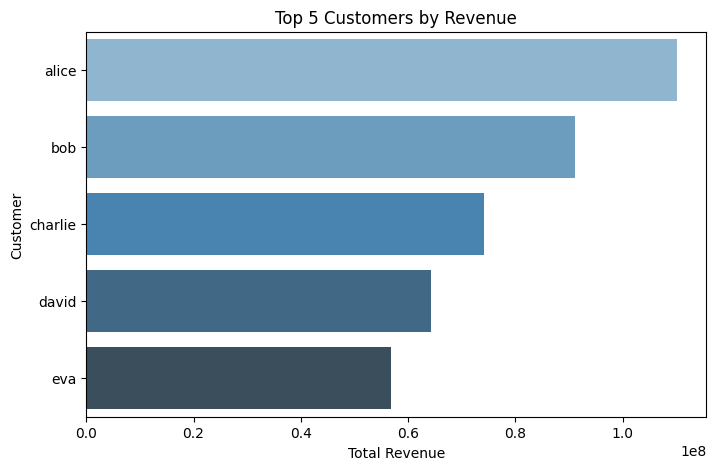

/tmp/ipython-input-2546661498.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='TotalAmount', y='Product', palette='Greens_d')


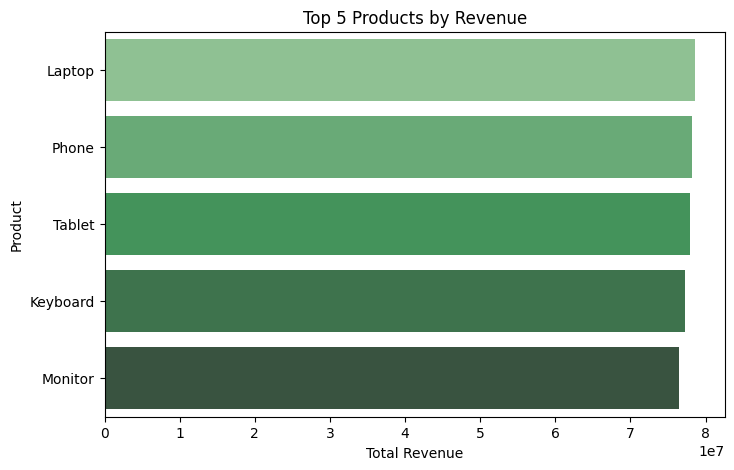

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_customers = master_df.groupby('CustomerName')['TotalAmount'].sum().sort_values(ascending=False).head(5).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=top_customers, x='TotalAmount', y='CustomerName', palette='Blues_d')
plt.title('Top 5 Customers by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Customer')
plt.show()

top_products = master_df.groupby('Product')['TotalAmount'].sum().sort_values(ascending=False).head(5).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=top_products, x='TotalAmount', y='Product', palette='Greens_d')
plt.title('Top 5 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.show()
